### This script makes example transition network plots

#### Use the transition csv made in build_dataset.ipynb OR real data from normalized_transitions.csv

In [1]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import to_rgba
from matplotlib.patches import FancyArrowPatch, Circle
from matplotlib.lines import Line2D
import networkx as nx
import numpy as np
import os
import pandas as pd

In [2]:
# Set the working directory 
path_to_csvs = r"C:\Users\irs3th\glp1r-reward-circuit"
if not os.path.exists(path_to_csvs):
    raise FileNotFoundError(f"Cannot find the path: '{path_to_csvs}'")

# Verify
os.chdir(path_to_csvs)
print("Current Working Directory:", os.getcwd())

Current Working Directory: C:\Users\irs3th\glp1r-reward-circuit


In [3]:
# Read csv from build_dataset
transition_df = pd.read_csv('normalized_transitions.csv') 

## Combining transitions by directionality

#### This step merges reciprocal transitions so that, for example, "groom to move" and "move to groom" are combined into a single, bidirectional transition

#### Only run this section if your dataset includes bidirectional transitions (the toy data does not so this code is for demonstration)

#### If you're not combining directions, you can skip this step and move on to averaging

In [4]:
# collect all transition columns (skip id + group)
transition_cols = [c for c in transition_df.columns if c not in ["id", "group"]]

pairs = {}
for col in transition_cols:
    src, dst = col.split("_", 1)  # split only on first underscore
    reverse = f"{dst}_{src}"
    if reverse in transition_cols:
        # build a standardized name (alphabetical to avoid duplicates)
        merged_name = "_".join(sorted([src, dst]))
        pairs.setdefault(merged_name, set()).update([col, reverse])
    else:
        # transitions without a reverse pair stay as is
        pairs[col] = {col}

# now combine
for merged_name, cols in pairs.items():
    transition_df[merged_name] = transition_df[list(cols)].sum(axis=1)

# drop the old directed columns
transition_df = transition_df[["id", "group"] + list(pairs.keys())]

# print(transition_df.head())


In [5]:
# Average normalized probability by group
avg_transition_matrix = (
    transition_df
    .drop(columns=["id"])     # remove numeric ID
    .groupby("group")
    .mean()
)
filtered = avg_transition_matrix.reset_index()

filtered = filtered[
    ~(
        filtered["group"].str.endswith("_light", na=False) |
        filtered["group"].str.startswith("veh", na=False) |
        filtered["group"].str.startswith("saline", na=False)|
        filtered["group"].str.startswith("no", na=False)

    )
]
filtered

,group,drink_groom,drink_move/explore,food motivated_groom,food motivated_move/explore,groom_move/explore,move/explore_shelter
0,LiCl,0.084274,0.249085,0.158139,0.325669,0.409962,0.272223
2,dan_sd,0.059745,0.283927,0.196456,0.388794,0.587288,0.412325
4,fed,0.152654,0.531467,0.183458,0.502945,0.841993,0.892718
5,lira_sd,0.029580,0.236761,0.134513,0.289156,0.561809,0.389642
7,orfo,0.145596,0.438256,0.160712,0.434943,0.560356,0.542864


### Plot for combined bidirectional transitions
### Aesthetic updates
#### - scaled colors for edges
#### - double arrowheads
#### - more space between nodes and edges

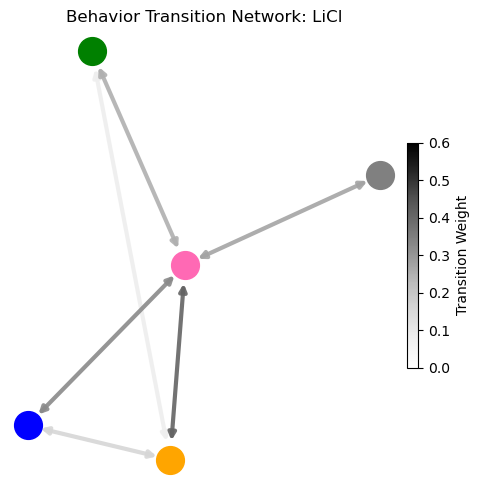

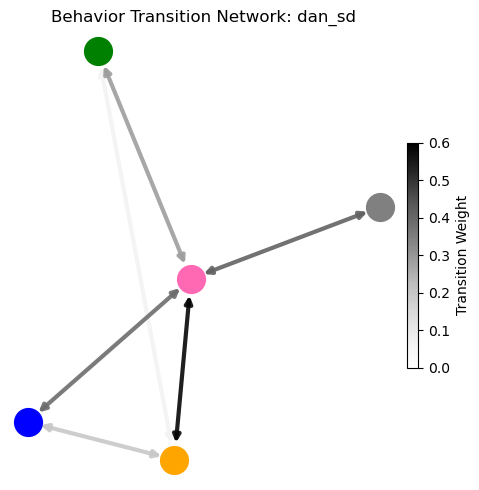

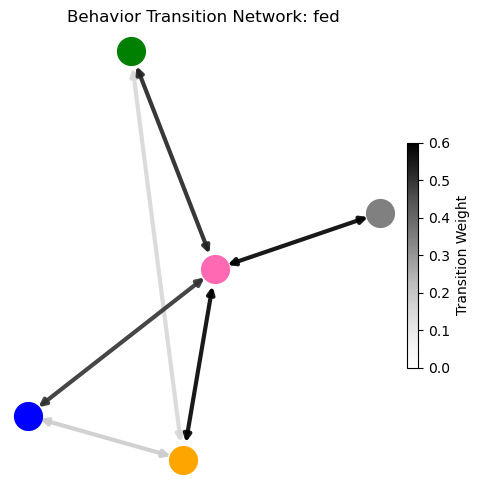

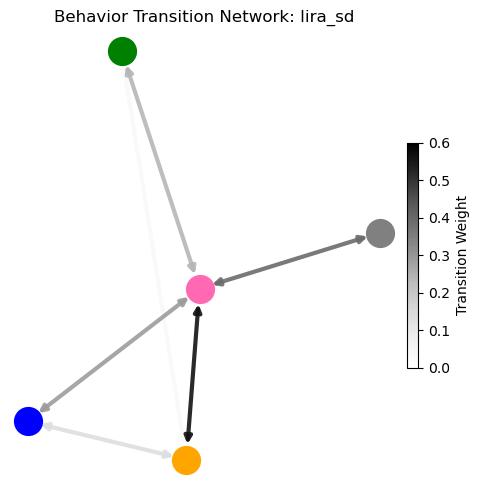

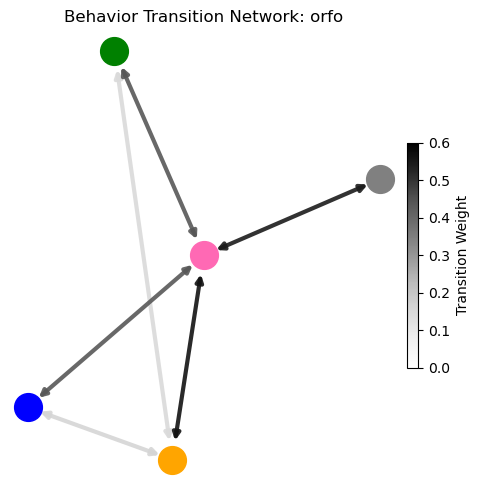

In [8]:
# Node colors
node_colors = {
    'food motivated': 'blue',
    'drink': 'green',
    'move/explore': 'hotpink',
    'groom': 'orange',
    'shelter': 'grey'
    }

behavior_numbering = {behavior: i + 1 for i, behavior in enumerate(node_colors)}
number_to_behavior = {v: k for k, v in behavior_numbering.items()}

# Calculate global max weight for scaling edges
# filtered: rows = groups, columns = numeric transition probabilities
global_max_weight = filtered.select_dtypes(float).max().max()

# Grayscale colormap for edges
cmap = cm.Greys

for _, row in filtered.iterrows():
    group = row["group"]   # fixed to get real group name
    G = nx.Graph() # undirected

    # Add edges with raw weights
    for col, value in row.items():
        try:
            val = float(value)
            if val > 0:
                source, target = col.rsplit('_', 1)
                if source in behavior_numbering and target in behavior_numbering:
                    G.add_edge(
                        behavior_numbering[source],
                        behavior_numbering[target],
                        weight=val
                    )
        except Exception:
            continue

    # Layout (increase `k` to spread nodes apart more)
    pos = nx.spring_layout(G, seed=42, k=1, weight="weight")

    plt.figure(figsize=(5, 5))
    ax = plt.gca()

    # Draw nodes
    for node, (x, y) in pos.items():
        ax.scatter(x, y, s=400, color=node_colors[number_to_behavior[node]], zorder=3)
       # ax.text(x, y, str(node), color="white", fontsize=10,
                #ha="center", va="center", zorder=4)

    # Normalize edge colors
    desired_max = 0.6  # adjust as needed
    norm = plt.Normalize(vmin=0, vmax=desired_max)

    node_radius = 0.05  # adjust to push arrows further away from nodes

    # Draw edges with "constant linewidth" but grayscale color
    for u, v, d in G.edges(data=True):
        weight = d["weight"]
        lw = 3  
        color = cmap(norm(weight))

        x1, y1 = pos[u]
        x2, y2 = pos[v]

        # Compute vector and shrink it at both ends
        dx, dy = x2 - x1, y2 - y1
        dist = np.sqrt(dx**2 + dy**2)
        if dist > 0:
            offset_x = dx / dist * node_radius
            offset_y = dy / dist * node_radius
            x1_off, y1_off = x1 + offset_x, y1 + offset_y
            x2_off, y2_off = x2 - offset_x, y2 - offset_y
        else:
            x1_off, y1_off, x2_off, y2_off = x1, y1, x2, y2

        # Draw double-headed arrow
        ax.annotate("",
                    xy=(x2_off, y2_off), xycoords="data",
                    xytext=(x1_off, y1_off), textcoords="data",
                    arrowprops=dict(arrowstyle="<|-|>",
                                    color=color,
                                    lw=lw,
                                    alpha=0.9),
                    zorder=2,
                    )

    # Add grayscale colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02)
    cbar.set_label("Transition Weight", fontsize=10)

    plt.title(f"Behavior Transition Network: {group}")
    plt.axis("off")
    plt.tight_layout()
    filename = os.path.join(path_to_csvs, f"{str(group).replace('/', '_')}.png")
    #plt.savefig(filename, format="eps", dpi=600)
    plt.show()
    plt.close()
